# Import Required Libraries
Import pandas for data handling and matplotlib.pyplot and seaborn for plotting.

In [53]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Enable inline plotting for Jupyter
%matplotlib inline

# Load CSV File
Use pandas to read the CSV file into a DataFrame. You can change the file path below to your CSV file.

In [54]:
# Load CSV File
csv_path = '/home/daniele/Desktop/tirocinio/energyBANERA-main/Data/new_measures/jetson_nano/Conv_3_0/Conv_1_256_3_0_nograd.csv'  # Change this to your CSV file path
csv_path_old = '/home/daniele/Desktop/tirocinio/energyBANERA-main/Data/Jetson_nano_power_record/Conv_3_0/Conv_1_256_3_0.csv'  # Change this to your CSV file path
df = pd.read_csv(csv_path)
df_old = pd.read_csv(csv_path_old)

# Display Data Overview
Show the first few rows and basic info about the DataFrame to understand its structure.

In [55]:
# Display Data Overview
display(df.head())
df.info()
df.describe()

,Sample,EVM1 VSHUNT Results (mV),EVM1 VBUS Results (V),EVM1 CURRENT Results (A),EVM1 POWER Results (W)
0,0,1.8675,5.15375,0.147716,0.762995
1,1,2.6150,5.11500,0.217911,1.113972
2,2,1.7700,5.14125,0.149242,0.770625
3,3,2.1150,5.12125,0.179151,0.919409
4,4,1.5300,5.14500,0.127573,0.656175


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sample                    10000 non-null  int64  
 1   EVM1 VSHUNT Results (mV)  10000 non-null  float64
 2   EVM1 VBUS Results (V)     10000 non-null  float64
 3   EVM1 CURRENT Results (A)  10000 non-null  float64
 4   EVM1 POWER Results (W)    10000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.8 KB


,Sample,EVM1 VSHUNT Results (mV),EVM1 VBUS Results (V),EVM1 CURRENT Results (A),EVM1 POWER Results (W)
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,3.606339,5.061463,0.300383,1.511990
std,2886.89568,1.481183,0.068096,0.123383,0.614908
min,0.00000,0.702500,4.967500,0.058598,0.301383
25%,2499.75000,4.175000,5.023750,0.347773,1.751073
50%,4999.50000,4.362500,5.026250,0.363338,1.823557
75%,7499.25000,4.422500,5.037500,0.368374,1.850262
max,9999.00000,5.672500,5.218750,0.471836,2.342394


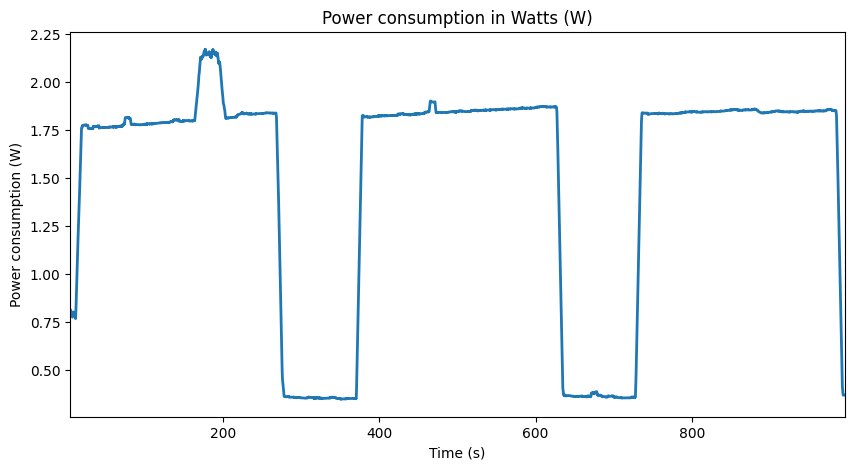

In [56]:
# Smooth the 'EVM1 POWER Results (W)' using a rolling mean
window_size = 75  # Adjust the window size as needed
smoothed = df['EVM1 POWER Results (W)'].rolling(window=window_size, center=True).mean()

smoothed = smoothed.dropna()
# Align 'Sample' values with the smoothed data index
sample_aligned = df['Sample'].iloc[smoothed.index]

time_sec = df['Sample'] * 0.1 # Assuming each sample corresponds to 0.1 seconds
#time_sec = df['Sample'] / 1000 # Assuming 'Sample' is in milliseconds, convert to seconds
time_sec_smoothed = time_sec.iloc[smoothed.index]

plt.figure(figsize=(10, 5))
plt.plot(time_sec_smoothed, smoothed, label=f'Rolling Mean (window={window_size})',linewidth=2.0)
plt.xlim(time_sec_smoothed.min(), time_sec_smoothed.max())
plt.xlabel('Time (s)')
plt.ylabel('Power consumption (W)')
plt.title('Power consumption in Watts (W)')
#plt.legend()
#plt.savefig("high_res_plot.svg",format='svg', dpi=300, bbox_inches='tight', transparent=False)
plt.show()



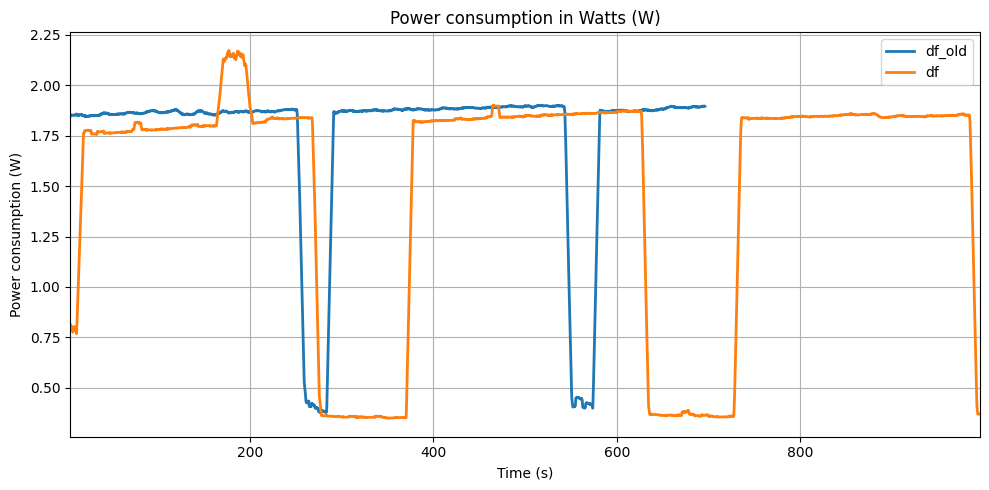

In [57]:
window_size = 75

smoothed_old = (
    df_old['EVM1 POWER Results (W)']
    .rolling(window=window_size, center=True)
    .mean()
    .dropna()
)

time_sec_old = df_old['Sample'] * 0.1
time_sec_smoothed_old = time_sec_old.iloc[smoothed_old.index]

# --- df ---
smoothed = (
    df['EVM1 POWER Results (W)']
    .rolling(window=window_size, center=True)
    .mean()
    .dropna()
)

time_sec = df['Sample'] * 0.1
time_sec_smoothed = time_sec.iloc[smoothed.index]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    time_sec_smoothed_old,
    smoothed_old,
    label='df_old',
    linewidth=2.0
)

ax.plot(
    time_sec_smoothed,
    smoothed,
    label='df',
    linewidth=2.0
)

ax.set_xlim(
    min(time_sec_smoothed_old.min(), time_sec_smoothed.min()),
    max(time_sec_smoothed_old.max(), time_sec_smoothed.max())
)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Power consumption (W)')
ax.set_title('Power consumption in Watts (W)')
ax.legend()
plt.grid(visible=True)
plt.tight_layout()
plt.show()

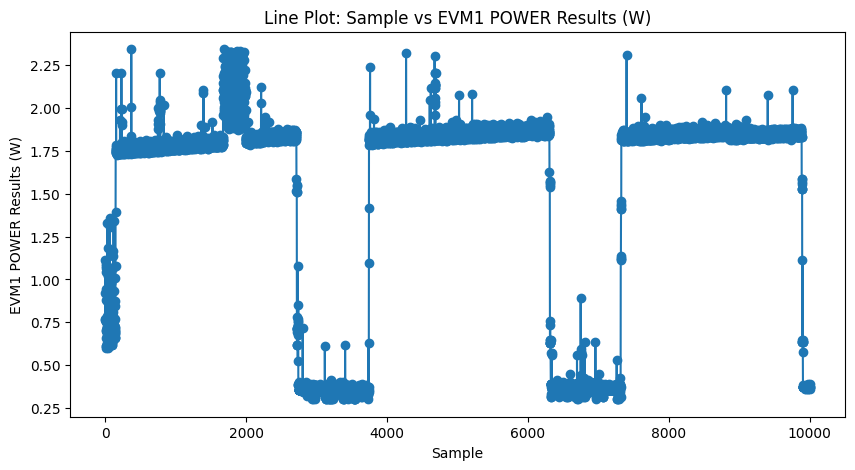

In [58]:
# Line plot: sample index (abscissa) vs 'EVM1 POWER Results' (ordinate)

plt.figure(figsize=(10, 5))
plt.plot(df['Sample'], df['EVM1 POWER Results (W)'], marker='o')
plt.xlabel('Sample')
plt.ylabel('EVM1 POWER Results (W)')
plt.title(f'Line Plot: Sample vs EVM1 POWER Results (W)')
plt.show()
